# Synthetic data

This notebook generates synthetic data.

- Synthetic users (ideal points) sampled from Gaussian clusters.
- Binary statements defined by pairs of points with a perpendicular decision boundary.
- Likert-style statements represented as ordered points along a gradient.
- Categorical statements defined by anchor points on the grid, with users assigned to the closest category (Voronoi partition).

All generated CSVs are saved into the `../data/` directory.

Required packages: `numpy`, `pandas`, `scipy`, `matplotlib`.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib as mpl
from numpy.random import Generator, PCG64
rng = Generator(PCG64(seed=0))

import sys; sys.path.insert(0, '..')
from ixplore.utils import add_noise

colormap = mpl.colors.LinearSegmentedColormap.from_list("coolwarm", ["red", "blue"])

def setup_ax(ax, title):
    """Common axis configuration for all spatial plots."""
    ax.set(xlim=[-1, 1], ylim=[-1, 1], aspect='equal', title=title)

def cutting_line(x1, y1, x2, y2):
    """Perpendicular bisector of the segment (x1,y1)-(x2,y2), clipped to [-1,1]."""
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    dx, dy = x1 - mx, y1 - my
    if dx == 0 and dy == 0:
        return np.array([mx, mx]), np.array([-1, 1])
    if dy == 0:
        return np.array([mx, mx]), np.array([-1, 1])
    slope = -dx / dy
    intercept = my - slope * mx
    x_line = np.array([-1, 1])
    return x_line, slope * x_line + intercept

## Users

Generate a set of synthetic users (ideal points) by sampling from several Gaussian clusters.
These user coordinates are saved to `../data/synthetic_users.csv` and plotted below.

In [2]:
# Means and covariance matrices
means = [[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5], [0, 0]]
covs  = [np.diag([0.025, 0.025]) for _ in means]

# Number of samples per class
n_samples_per_class = 50
noise_multiplier = 3  # each noise unit flips this % of features

# Generate samples for each Gaussian class
users_list = []
for i, (mean, cov) in enumerate(zip(means, covs)):
    samples = multivariate_normal.rvs(mean=mean, cov=cov, size=n_samples_per_class, random_state=rng.integers(1_000_000))
    df = pd.DataFrame(samples, columns=['x', 'y'])
    df['party'] = i
    users_list.append(df)

# Combine all classes into one DataFrame
users = pd.concat(users_list, ignore_index=True)
users.index.name = 'id'
users['noise'] = rng.integers(0, 6, size=len(users))  # [0, 5]
users['color'] = 'C'+ users['party'].astype(str)
# Save to CSV
users.to_csv('../data/synthetic_users.csv', index=True, float_format="%.3f")
users

,x,y,party,noise,color
id,,,,,
0,-0.468133,-0.583416,0,0,C0
1,-0.244029,-0.432206,0,0,C0
2,-0.345982,-0.412084,0,0,C0
3,-0.513863,-0.558170,0,1,C0
4,-0.418988,-0.586317,0,4,C0
...,...,...,...,...,...
245,-0.154228,0.210119,4,1,C4
246,0.012340,-0.171272,4,1,C4
247,-0.079014,-0.067357,4,1,C4


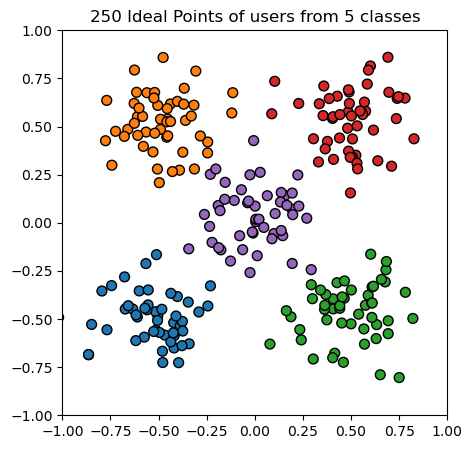

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(users.x, users.y, color=users.color, s=50, edgecolors='black')
setup_ax(ax, f'{len(users)} Ideal Points of users from 5 classes')
plt.show()

## Binary Statements

Create binary statements from pairs of points. For each statement we compute a perpendicular (cutting) line that defines the decision boundary between the two options.
The generated statements and user responses are saved to `../data/binary_statements.csv` and `../data/binary_reactions.csv`.

In [4]:
# Create a DataFrame with n_binary random statements
n_binary = 80
binary_statements = rng.uniform(-1, 1, (n_binary, 4))
binary_statements = pd.DataFrame(binary_statements, columns=['x1', 'y1', 'x2', 'y2'], index=range(n_binary))
binary_statements['feature'] = "Q" + (binary_statements.index + 1).astype(str)
binary_statements.head()

,x1,y1,x2,y2,feature
0,-0.750891,-0.423338,0.172246,0.108181,Q1
1,0.619422,0.120952,-0.423158,-0.174207,Q2
2,0.636242,0.253013,0.918155,-0.261191,Q3
3,0.105223,0.187848,0.696582,-0.709053,Q4
4,-0.186979,0.819918,-0.913866,0.645413,Q5


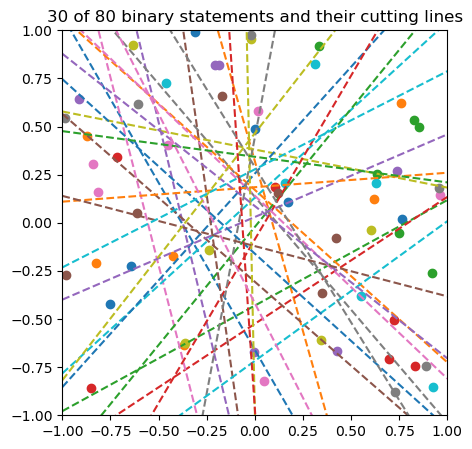

In [5]:
# Plotting (first 30 features only)
fig, ax = plt.subplots(figsize=(5, 5))

for _, row in binary_statements.iloc[:30].iterrows():
    c = 'C' + str(row.name)
    ax.scatter([row.x1, row.x2], [row.y1, row.y2], c=c)
    xl, yl = cutting_line(row.x1, row.y1, row.x2, row.y2)
    ax.plot(xl, yl, c=c, linestyle='--')

setup_ax(ax, f'30 of {n_binary} binary statements and their cutting lines')
plt.show()

In [6]:
# Pairwise distances: users x statements
A = cdist(users[['x','y']].values, binary_statements[['x1','y1']].values, metric='euclidean')
A = pd.DataFrame(A, columns=binary_statements.feature, index=users.index)

B = cdist(users[['x','y']].values, binary_statements[['x2','y2']].values, metric='euclidean')
B = pd.DataFrame(B, columns=binary_statements.feature, index=users.index)

# Generate reactions: 1 if closer to 'x2,y2', 0 otherwise
binary_reactions = (A > B).astype(int)
binary_reactions.index.name = 'id'
binary_reactions.to_csv('../data/binary_reactions.csv', index=True, float_format="%.3f")

# Noisy version
keep_fractions = 1 - users.noise.values * noise_multiplier / 100.0
binary_reactions_noisy = add_noise(binary_reactions, keep_fractions, generator=rng)
binary_reactions_noisy.to_csv('../data/binary_reactions_noisy.csv', index=True, float_format="%.3f")

binary_reactions

feature,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q71,Q72,Q73,Q74,Q75,Q76,Q77,Q78,Q79,Q80
id,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,1,1,0,1,0,0,...,0,0,1,0,0,1,1,0,0,1
1,0,1,0,0,0,1,1,1,0,0,...,0,0,1,0,0,1,1,0,0,1
2,0,1,0,0,1,1,1,1,0,0,...,0,0,1,0,0,1,1,0,0,1
3,0,1,0,0,1,1,0,1,0,0,...,0,0,1,0,0,0,1,0,0,1
4,0,1,0,0,1,1,0,1,0,0,...,0,0,1,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1,1,0,0,0,0,1,1,0,1,...,0,0,1,0,0,1,0,1,0,1
246,1,1,0,0,0,0,1,1,0,0,...,0,0,1,0,0,1,1,0,0,1
247,1,1,0,0,0,0,1,1,0,0,...,0,0,1,0,0,1,0,0,0,1


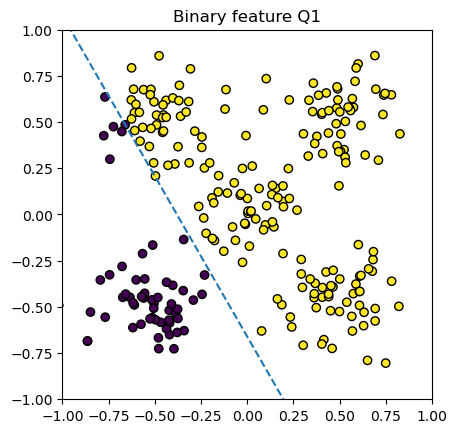

In [7]:
def plot_binary_feature(i):
    fig, ax = plt.subplots()
    row = binary_statements.iloc[i]
    xl, yl = cutting_line(row.x1, row.y1, row.x2, row.y2)
    ax.plot(xl, yl, c='C0', linestyle='--')
    ax.scatter(users.x, users.y, c=binary_reactions.iloc[:, i], edgecolors='k')
    setup_ax(ax, f'Binary feature Q{i+1}')
    
plot_binary_feature(0)

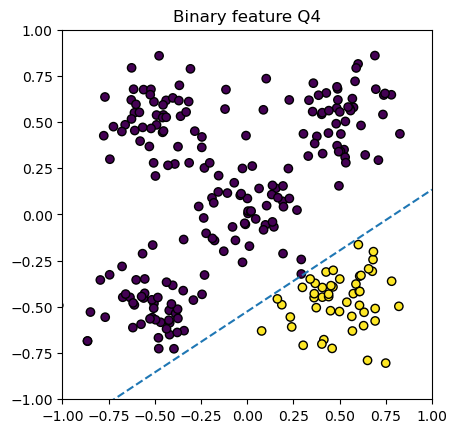

In [8]:
plot_binary_feature(3)

## Likert Scales

Generate multi-option (Likert-style) statements by interpolating between two anchor points to form an ordered set of options.
Save the statement definitions to `../data/likert_statements.csv` and the simulated user answers to `../data/likert_reactions.csv`.

In [9]:
# Create a DataFrame with n_likert random anchor pairs and interpolate intermediate points
n_likert = 70
likert_statements = rng.uniform(-1, 1, (n_likert, 4))
likert_statements = pd.DataFrame(likert_statements, columns=['x1', 'y1', 'x4', 'y4'])

f = lambda row: np.hstack([k*row.loc[['x4','y4']].values+(1-k)*row.loc[['x1','y1']].values for k in [0.33, 0.66]])
likert_statements[['x2','y2','x3', 'y3']] = likert_statements.apply(f, axis=1, result_type='expand')
likert_statements['feature'] = "Q" + (likert_statements.index + 1).astype(str)

likert_statements = likert_statements.sort_index(axis=1)
likert_statements.head()

,feature,x1,x2,x3,x4,y1,y2,y3,y4
0,Q1,-0.220571,-0.305182,-0.389794,-0.476970,-0.938291,-0.451891,0.034509,0.535648
1,Q2,-0.657603,-0.360979,-0.064356,0.241256,0.382479,0.223628,0.064776,-0.098890
2,Q3,0.467338,0.239585,0.011832,-0.222823,0.124485,0.141764,0.159042,0.176845
3,Q4,-0.940968,-0.902414,-0.863859,-0.824137,0.145304,0.336663,0.528022,0.725180
4,Q5,0.827333,0.568148,0.308963,0.041924,0.930829,0.796447,0.662066,0.523612


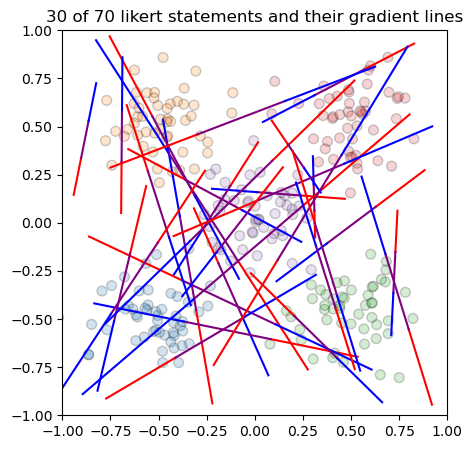

In [10]:
def plot_gradient_line(row, ax=None):
    """Plot a 4-point gradient line (red→blue) for a likert statement row."""
    coords = row.drop('feature').values.reshape(2, 4).T  # (4, 2)
    ax = ax or plt.gca()
    for i in range(3):
        ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], color=colormap(i / 2.))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(users.x, users.y, color=users.color, s=50, edgecolors='black', alpha=0.2)

for _, row in likert_statements.iloc[:30].iterrows():
    plot_gradient_line(row, ax)

setup_ax(ax, f'30 of {n_likert} likert statements and their gradient lines')
plt.show()

In [11]:
options = []

for i in range(4):
    answer_points = likert_statements.iloc[:, [i+1, i+5]].values  # shape: (n_likert, 2)
    dists = cdist(users[['x','y']].values, answer_points, metric='euclidean')
    options.append(dists)

# Stack distances: shape (4, n_users, n_likert)
options = np.array(options)

# Choose the index of the minimum distance along the first axis (closest option)
likert_reactions = options.argmin(axis=0).astype(int)

# Convert to DataFrame
likert_reactions = pd.DataFrame(likert_reactions, columns=likert_statements.feature, index=users.index)
likert_reactions.index.name = 'id'
likert_reactions.to_csv('../data/likert_reactions.csv', index=True, float_format="%.3f")

# Noisy version
keep_fractions = 1 - users.noise.values * noise_multiplier / 100.0
likert_reactions_noisy = add_noise(likert_reactions, keep_fractions, generator=rng)
likert_reactions_noisy.to_csv('../data/likert_reactions_noisy.csv', index=True, float_format="%.3f")

likert_reactions

feature,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q61,Q62,Q63,Q64,Q65,Q66,Q67,Q68,Q69,Q70
id,,,,,,,,,,,,,,,,,,,,,
0,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
1,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
2,1,2,3,0,3,1,1,2,2,3,...,0,2,2,1,2,2,3,1,2,2
3,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,0,2,2
4,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2,2,3,1,3,2,0,0,2,1,...,3,2,0,2,2,2,2,2,1,0
246,1,3,2,0,3,1,1,1,1,2,...,1,1,2,2,1,2,2,3,2,0
247,2,2,2,0,3,1,1,1,2,2,...,2,2,1,2,2,2,2,2,1,0


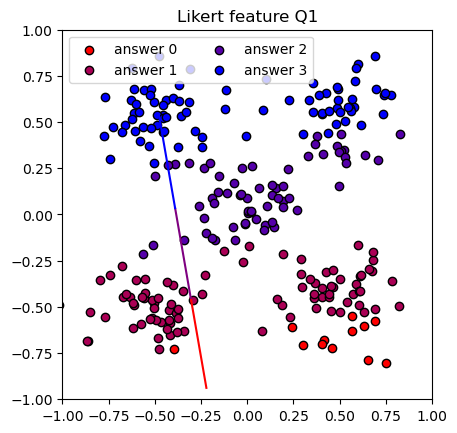

In [12]:
def plot_likert_feature(i):
    fig, ax = plt.subplots()
    data = likert_reactions.iloc[:, i]
    for c in range(4):
        mask = data == c
        ax.scatter(users.loc[mask, 'x'], users.loc[mask, 'y'],
                   color=colormap(c / 3.), edgecolors='k', label=f'answer {c}')
    plot_gradient_line(likert_statements.iloc[i, :], ax)
    setup_ax(ax, f'Likert feature Q{i+1}')
    ax.legend(ncol=2)
    
plot_likert_feature(0)

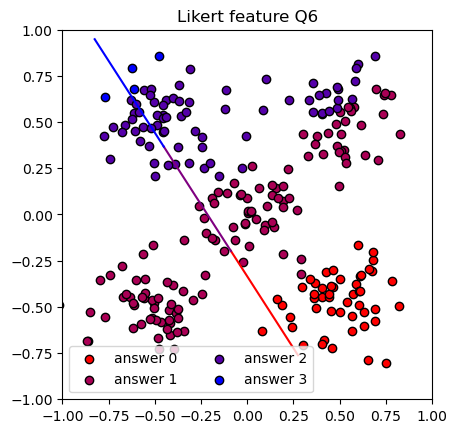

In [13]:
plot_likert_feature(5)

## Categorical Statements

Generate categorical statements by sampling anchor points on the grid. For each feature we sample a set of category centres (e.g. 3 categories named A, B, C). Every user is assigned to the category whose centre is closest to the user's ideal point — this creates a Voronoi-style partition of the space.

The simulated user responses are saved to `../data/categorical_reactions.csv`.

In [14]:
# Number of categorical features and categories per feature
n_categorical = 60
K = 3  # number of categories (A, B, C)
category_labels = list("ABC")

# Sample K anchor points per feature on the [-1, 1] grid
cat_anchors = rng.uniform(-1, 1, (n_categorical, K, 2))

# Build a statement definitions DataFrame for inspection
rows = []
for q in range(n_categorical):
    row = {"feature": f"Q{q+1}"}
    for k in range(K):
        row[f"x_{category_labels[k]}"] = cat_anchors[q, k, 0]
        row[f"y_{category_labels[k]}"] = cat_anchors[q, k, 1]
    rows.append(row)

cat_statements = pd.DataFrame(rows)
cat_statements.head()

,feature,x_A,y_A,x_B,y_B,x_C,y_C
0,Q1,-0.025703,0.457126,0.706595,0.164200,0.290287,-0.729479
1,Q2,0.686365,0.340307,0.215626,-0.547211,0.223417,0.793744
2,Q3,0.980957,0.492131,-0.670317,-0.259300,-0.681611,-0.236069
3,Q4,0.313999,0.621405,0.788154,0.840775,-0.045620,-0.998860
4,Q5,-0.485474,-0.558353,0.822693,-0.323233,-0.732911,-0.942312


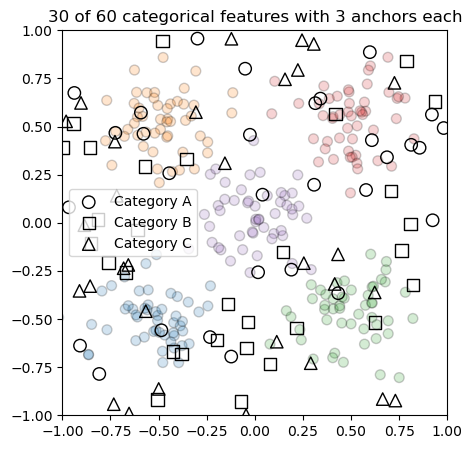

In [15]:
# Plot first 30 category anchors overlaid on users
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(users.x, users.y, color=users.color, s=50, edgecolors='black', alpha=0.2)

markers = ['o', 's', '^']
for k, label in enumerate(category_labels):
    ax.scatter(cat_anchors[:30, k, 0], cat_anchors[:30, k, 1],
               marker=markers[k], s=80, edgecolors='black', facecolors='none',
               label=f"Category {label}")

ax.legend()
setup_ax(ax, f'30 of {n_categorical} categorical features with {K} anchors each')
plt.show()

In [16]:
# For each user and each feature, assign the closest category
user_coords = users[['x', 'y']].values

cat_reactions = np.empty((len(users), n_categorical), dtype=object)

for q in range(n_categorical):
    dists = cdist(user_coords, cat_anchors[q])
    closest = dists.argmin(axis=1)
    cat_reactions[:, q] = [category_labels[c] for c in closest]

cat_reactions = pd.DataFrame(cat_reactions,
                             columns=[f"Q{q+1}" for q in range(n_categorical)],
                             index=users.index)
cat_reactions.index.name = 'id'
cat_reactions.to_csv('../data/categorical_reactions.csv', index=True)

# Noisy version
keep_fractions = 1 - users.noise.values * noise_multiplier / 100.0
cat_reactions_noisy = add_noise(cat_reactions, keep_fractions, generator=rng)
cat_reactions_noisy.to_csv('../data/categorical_reactions_noisy.csv', index=True)

cat_reactions.head(10)

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q51,Q52,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60
id,,,,,,,,,,,,,,,,,,,,,
0,C,B,B,C,A,C,B,B,B,C,...,B,A,B,A,A,A,A,A,B,B
1,C,B,B,C,A,C,B,B,B,A,...,B,A,B,A,A,A,C,B,B,B
2,C,B,B,C,A,C,B,B,B,A,...,B,A,B,C,A,A,C,B,B,B
3,C,B,B,C,A,C,B,B,B,A,...,B,A,B,A,A,A,A,A,B,B
4,C,B,B,C,A,C,B,B,B,C,...,B,A,B,A,A,A,A,A,B,B
5,C,B,B,C,A,C,B,B,B,C,...,B,A,B,A,A,A,A,A,B,B
6,C,B,B,C,A,C,B,B,B,A,...,B,A,B,C,A,A,B,B,B,B
7,C,B,B,C,A,C,B,B,B,A,...,B,A,B,C,A,A,A,B,B,B
8,C,B,B,C,A,C,B,B,B,A,...,B,A,B,C,A,A,A,B,B,B


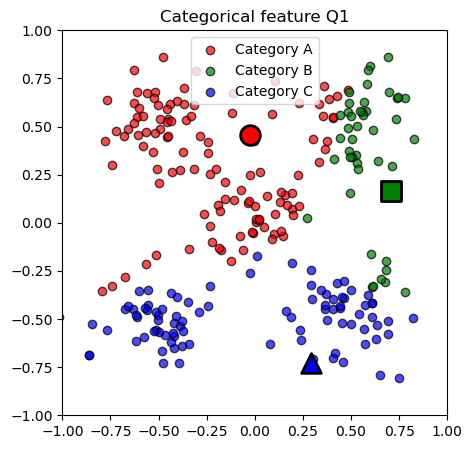

In [17]:
CAT_COLORS = {'A': 'red', 'B': 'green', 'C': 'blue'}
CAT_MARKERS = {'A': 'o', 'B': 's', 'C': '^'}

def plot_categorical_feature(i):
    fig, ax = plt.subplots(figsize=(5, 5))
    data = cat_reactions.iloc[:, i]

    for label in category_labels:
        mask = data == label
        ax.scatter(users.loc[mask, 'x'], users.loc[mask, 'y'],
                   color=CAT_COLORS[label], edgecolors='k',
                   label=f'Category {label}', alpha=0.7)

    for k, label in enumerate(category_labels):
        ax.scatter(cat_anchors[i, k, 0], cat_anchors[i, k, 1],
                   marker=CAT_MARKERS[label], s=200,
                   color=CAT_COLORS[label], edgecolors='black', linewidths=2,
                   zorder=5)

    setup_ax(ax, f'Categorical feature Q{i+1}')
    ax.legend(ncol=1, loc='upper center')

plot_categorical_feature(0)

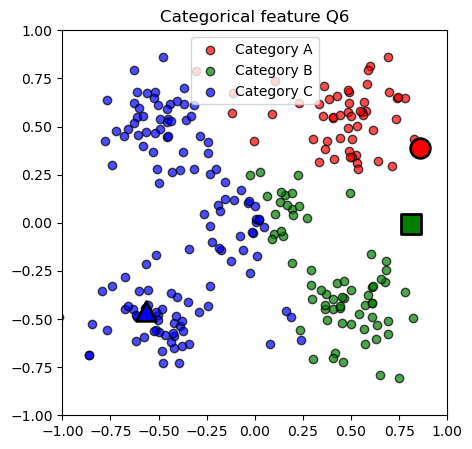

In [18]:
plot_categorical_feature(5)

## Overview

Count how many users share an identical response pattern (i.e. duplicate rows) in each of the three reaction datasets.

In [19]:
datasets = {
    f"Binary ({n_binary})": binary_reactions,
    f"Binary noisy ({n_binary})": binary_reactions_noisy,
    f"Likert ({n_likert})": likert_reactions,
    f"Likert noisy ({n_likert})": likert_reactions_noisy,
    f"Categorical ({n_categorical})": cat_reactions,
    f"Categorical noisy ({n_categorical})": cat_reactions_noisy,
}

summary = []
for name, df in datasets.items():
    n_total = len(df)
    n_unique = df.drop_duplicates().shape[0]
    n_duplicated = n_total - n_unique
    n_uniform = (df.nunique() == 1).sum()
    summary.append({"Dataset": name,
                    "Total users": n_total,
                    "Unique patterns": n_unique,
                    "Duplicate users": n_duplicated,
                    "Uniform features": n_uniform})

pd.DataFrame(summary)

,Dataset,Total users,Unique patterns,Duplicate users,Uniform features
0,Binary (80),250,176,74,0
1,Binary noisy (80),250,249,1,0
2,Likert (70),250,230,20,0
3,Likert noisy (70),250,250,0,0
4,Categorical (60),250,189,61,0
5,Categorical noisy (60),250,250,0,0
